# Rejection-free Monte Carlo: the Lennard-Jones fluid

This notebook reproduces the Lennard-Jones example of E.A.J.F. Peters and G. de With, *Rejection-free Monte Carlo sampling for general potentials*, Phys. Rev. E **85**, 026703 (2012), with `spheropack.rejection_free`.

In the rejection-free method all particles move along straight lines. For every pair, the increase of the pair potential along the path is accumulated (decreases are free), and the pair reflects like an elastic collision when the accumulated increase reaches $-kT\ln u$ with $u$ uniform in $(0, 1]$. No move is ever rejected, and positions sampled at equidistant times follow the canonical distribution $\exp(-U/kT)$.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/computational-chemical-engineering/spheropack/blob/main/docs/notebooks/05_rejection_free_lennard_jones.ipynb) [![Download notebook](https://img.shields.io/badge/download-notebook-orange?logo=jupyter)](https://computational-chemical-engineering.github.io/spheropack/notebooks/05_rejection_free_lennard_jones.ipynb)

In [ ]:
# Install spheropack when it is not available (for example on Google Colab).
import importlib.util

if importlib.util.find_spec("spheropack") is None:
    %pip install -q spheropack

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import spheropack as sp
from spheropack import rejection_free as rf

## The potential

The truncated and shifted Lennard-Jones potential, $U(r) = 4\epsilon[(\sigma/r)^{12} - (\sigma/r)^6] - U_\mathrm{LJ}(r_c)$ for $r < r_c = 2.5\sigma$. Approaching particles accumulate potential increase only inside the minimum at $r = 2^{1/6}\sigma$; separating particles accumulate it between the minimum and the cutoff.

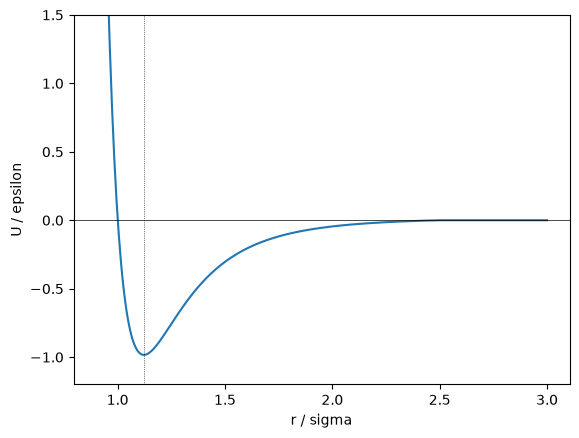

In [2]:
lj = rf.LennardJones(epsilon=1.0, sigma=1.0, cutoff=2.5)
r = np.linspace(0.9, 3.0, 400)
plt.plot(r, lj(r))
plt.axhline(0, color="k", lw=0.5)
plt.axvline(2 ** (1 / 6), color="k", lw=0.5, ls=":")
plt.ylim(-1.2, 1.5)
plt.xlabel("r / sigma"); plt.ylabel("U / epsilon");

## The state point of the paper

1000 particles at number density $\rho = 0.317$ and temperature $T = 1.085$ (Lennard-Jones units), close to the critical point. To avoid huge initial energies the particles start from a random packing of spheres of diameter $0.9\sigma$, generated with `spheropack.pack`.

In [3]:
n, rho, T = 1000, 0.317, 1.085
L = (n / rho) ** (1 / 3)
start = sp.pack(n=n, radii=0.45, container=sp.PeriodicBox(L), seed=1)
system = rf.System(start.positions, box=start.container, potential=lj, kT=T, seed=1)
system

System(n=1000, dim=3, density=0.317, potential=LennardJones(rc=2.5), kT=1.085, time=0, n_reflections=0)

Equilibration: the potential energy per particle settles within a few tens of time units (time is the contour length of the moves; the move velocities are Gaussian with unit variance per component).

574141 reflections in 27.7 s


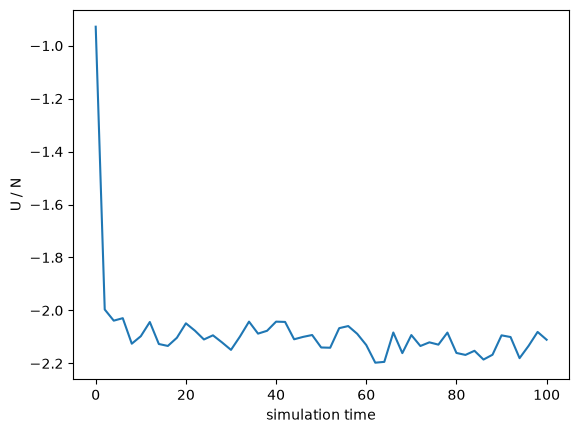

In [4]:
times, energies = [0.0], [system.potential_energy() / n]
t0 = time.perf_counter()
for _ in range(50):
    system.run(2.0)
    times.append(system.time)
    energies.append(system.potential_energy() / n)
print(f"{system.n_reflections} reflections in {time.perf_counter() - t0:.1f} s")
plt.plot(times, energies)
plt.xlabel("simulation time"); plt.ylabel("U / N");

## Radial distribution function

Sampling every 2 time units; `rf.radial_distribution` advances the system and averages $g(r)$ over the samples. The reference data of the paper are three long Metropolis runs and the paper's own rejection-free run.

sampling took 175 s, 4064257 reflections in total
mean |difference| on bins of 0.05: 0.0022


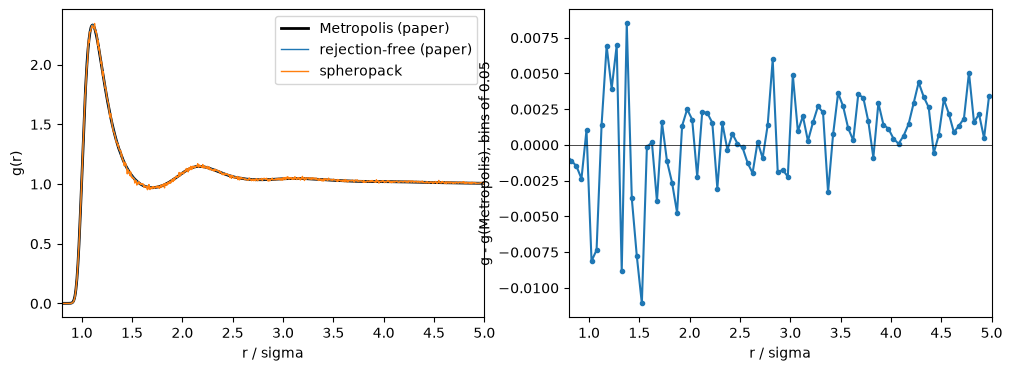

In [5]:
t0 = time.perf_counter()
g = rf.radial_distribution(system, n_samples=300, interval=2.0, r_max=5.0, bins=1000)
print(f"sampling took {time.perf_counter() - t0:.0f} s, {system.n_reflections} reflections in total")

def load_reference(name):
    local = Path("../data") / name
    if local.exists():
        return np.loadtxt(local)
    url = f"https://raw.githubusercontent.com/computational-chemical-engineering/spheropack/main/docs/data/{name}"
    return np.loadtxt(url)

ref = load_reference("GofR_LJ_all.dat")
metropolis = ref[:, [1, 3, 5]].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ref[:, 0], metropolis, "k-", lw=2, label="Metropolis (paper)")
axes[0].plot(ref[:, 6], ref[:, 7], lw=1, label="rejection-free (paper)")
axes[0].plot(g.r, g.g, lw=1, label="spheropack")
axes[0].set_xlim(0.8, 5); axes[0].set_xlabel("r / sigma"); axes[0].set_ylabel("g(r)"); axes[0].legend()

coarse = lambda a: a.reshape(100, 10).mean(axis=1)
axes[1].plot(coarse(g.r), coarse(g.g) - coarse(metropolis), "o-", ms=3)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_xlim(0.8, 5); axes[1].set_xlabel("r / sigma"); axes[1].set_ylabel("g - g(Metropolis), bins of 0.05")
print(f"mean |difference| on bins of 0.05: {np.abs(coarse(g.g) - coarse(metropolis)).mean():.4f}")

The rejection-free sampling reproduces the Metropolis result within the statistical noise. The paper's rejection-free run (time 339240) is far longer than this example; the noise of the difference shrinks with the square root of the sampling time.

## The DPD liquid of the paper

The second example of the paper: DPD particles (soft repulsion $\frac{a}{2}(1 - r/r_c)^2$) at the conventional density $\rho = 3$ with $a = 25\,kT$, where the particles overlap strongly.

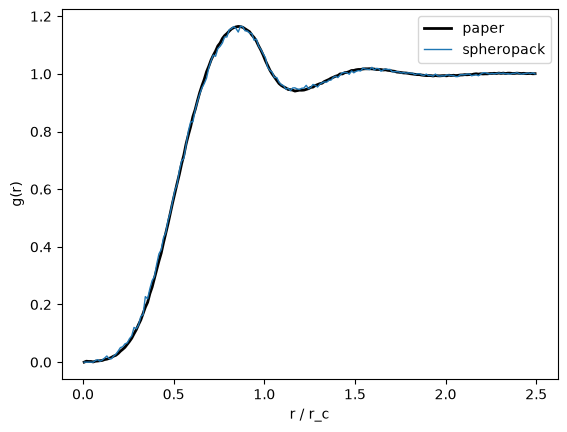

In [6]:
dpd = rf.System(n=375, box=sp.PeriodicBox(5.0), potential=rf.DPD(a=25.0), kT=1.0, seed=2)
dpd.run(20.0)
g_dpd = rf.radial_distribution(dpd, n_samples=400, interval=0.5, r_max=2.5, bins=200)
ref_dpd = load_reference("GofR_DPD_110925.dat")
plt.plot(ref_dpd[:, 0], ref_dpd[:, 1], "k-", lw=2, label="paper")
plt.plot(g_dpd.r, g_dpd.g, lw=1, label="spheropack")
plt.xlabel("r / r_c"); plt.ylabel("g(r)"); plt.legend();

## Notes

- The move velocities are not physical momenta: their magnitude only sets the time scale of the moves, and they are conserved by the reflections. `system.redraw_velocities()` draws new ones; the paper found that this is not needed for ergodicity.
- Any pair potential with at most one minimum fits the method: `rf.LennardJones`, `rf.WCA`, `rf.DPD`, `rf.SoftSpheres` (harmonic, Hertzian) and `rf.HardSpheres`, where every approach to contact reflects.